# 04 — Modelagem ML (Small Data) | Vale do São Francisco

## Objetivo
Modelar a **produção anual (toneladas)** de **UVA** e **MANGA** usando **features climáticas anuais** (sem leakage).

## Premissas do projeto
- **Produção (IBGE/PAM) é anual** → target anual.
- Dataset é pequeno (~24 amostras por cultura) → foco em **robustez** e **controle de overfitting**.
- Modelos **separados por cultura** (UVA e MANGA).

## Saídas
- Modelos: `models/xgboost_uva.pkl`, `models/xgboost_manga.pkl`
- Métricas: `models/metrics.json`
- Figura resumo: `models/model_results.png`

> Nota: com poucas amostras, métricas podem oscilar bastante. R² entre **0.40–0.60** já é excelente para clima-only.


In [6]:
from __future__ import annotations

from pathlib import Path
import json
import pickle
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBRegressor

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 1) Caminhos e carregamento do dataset

Boas práticas:
- Caminhos **relativos ao projeto** (funciona local, VSCode, etc.)
- Pasta `models/` criada automaticamente


In [7]:
PROJECT_ROOT = Path.cwd()
DATASET_PATH = PROJECT_ROOT / "dataset_ml_anual.csv"

OUTPUT_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATASET_PATH:", DATASET_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset não encontrado em: {DATASET_PATH}\n"
        f"Dica: ajuste o caminho ou coloque o arquivo em data/processed/."
    )

df = pd.read_csv(DATASET_PATH)

print("Dataset:", df.shape)
print("Período:", df["ano"].min(), "-", df["ano"].max())
print("Produtos:", df["produto"].unique())
print("Municípios:", df["municipio"].unique())

df.head(5)

DATASET_PATH: /content/dataset_ml_anual.csv
OUTPUT_DIR: /content/models
Dataset: (48, 15)
Período: 2013 - 2024
Produtos: ['Manga' 'Uva']
Municípios: ['JUAZEIRO' 'PETROLINA']


,ano,municipio,produto,quantidade_produzida_t,temp_media_anual,temp_max_anual,temp_min_anual,precipitacao_total_anual_mm,eto_total_anual_mm,vento_medio_anual,gdd_total_anual,deficit_hidrico_total_anual_mm,indice_stress_medio_anual,amplitude_termica_media_anual,dias_temp_otima_total_anual
0,2013,JUAZEIRO,Manga,210236,27.137606,38.4,16.5,311.6,2276.95,22.448316,205.651267,-1965.35,84.876705,15.416667,255.787382
1,2013,JUAZEIRO,Uva,27940,27.137606,38.4,16.5,311.6,2276.95,22.448316,205.651267,-1965.35,84.876705,15.416667,255.787382
2,2014,JUAZEIRO,Manga,55380,26.353959,37.2,17.9,289.6,2158.91,22.974942,196.247512,-1869.31,85.611794,14.800000,276.633543
3,2014,JUAZEIRO,Uva,39400,26.353959,37.2,17.9,289.6,2158.91,22.974942,196.247512,-1869.31,85.611794,14.800000,276.633543
4,2015,JUAZEIRO,Manga,44730,27.273674,37.8,17.3,270.3,2344.09,22.498347,207.284094,-2073.79,87.760188,14.891667,254.240278


## 2) Preparação: ordenação temporal e encoding

### Por que isso importa?
- Em séries temporais, **a ordem dos dados é crítica**.
- Para XGBoost, codificamos município como número (`LabelEncoder`) apenas para permitir treino.
  - Em cenários maiores, considerar One-Hot/Target Encoding.

Também criaremos `ano_index` como uma tendência linear opcional.
> Rodaremos o treino **com e sem** `ano_index` para verificar se o modelo está “aprendendo tendência” ao invés de clima.


In [8]:
# Ordenação temporal (importante)
df = df.sort_values(["produto", "municipio", "ano"]).reset_index(drop=True)

# Encode município
le_mun = LabelEncoder()
df["municipio_encoded"] = le_mun.fit_transform(df["municipio"])

# Tendência temporal (opcional)
df["ano_index"] = df["ano"] - df["ano"].min()

df[["ano", "municipio", "municipio_encoded", "produto", "ano_index"]].head(10)


,ano,municipio,municipio_encoded,produto,ano_index
0,2013,JUAZEIRO,0,Manga,0
1,2014,JUAZEIRO,0,Manga,1
2,2015,JUAZEIRO,0,Manga,2
3,2016,JUAZEIRO,0,Manga,3
4,2017,JUAZEIRO,0,Manga,4
5,2018,JUAZEIRO,0,Manga,5
6,2019,JUAZEIRO,0,Manga,6
7,2020,JUAZEIRO,0,Manga,7
8,2021,JUAZEIRO,0,Manga,8
9,2022,JUAZEIRO,0,Manga,9


## 3) Seleção de features (anti-multicolinearidade)

Com base na matriz de correlação, removemos features altamente redundantes:
- `gdd_total_anual` (correlação ~1.0 com `temp_media_anual`)
- `deficit_hidrico_total_anual_mm` (muito correlacionado com precipitação/ETO)
- `indice_stress_medio_anual` (muito correlacionado com precipitação/ETO)

Mantemos um conjunto enxuto e representativo, adequado para *small data*.


In [9]:
TARGET = "quantidade_produzida_t"

FEATURES_CLIMA = [
    "temp_media_anual",              # energia térmica
    "precipitacao_total_anual_mm",   # entrada de água
    "eto_total_anual_mm",            # demanda atmosférica
    "vento_medio_anual",             # fator físico
    "amplitude_termica_media_anual", # stress térmico
    "dias_temp_otima_total_anual",   # janela de oportunidade
]

FEATURES_BASE = ["municipio_encoded"] + FEATURES_CLIMA
FEATURES_WITH_TREND = ["municipio_encoded", "ano_index"] + FEATURES_CLIMA

print("Features (sem tendência):", FEATURES_BASE)
print("Features (com tendência):", FEATURES_WITH_TREND)


Features (sem tendência): ['municipio_encoded', 'temp_media_anual', 'precipitacao_total_anual_mm', 'eto_total_anual_mm', 'vento_medio_anual', 'amplitude_termica_media_anual', 'dias_temp_otima_total_anual']
Features (com tendência): ['municipio_encoded', 'ano_index', 'temp_media_anual', 'precipitacao_total_anual_mm', 'eto_total_anual_mm', 'vento_medio_anual', 'amplitude_termica_media_anual', 'dias_temp_otima_total_anual']


## 4) Split temporal (treino < 2022 | teste >= 2022)

- Treino: 2013–2021
- Teste: 2022–2024 (holdout out-of-time)

> Importante: com poucos anos no teste, métricas no holdout podem variar bastante.


In [10]:
YEAR_SPLIT = 2022

df_train = df[df["ano"] < YEAR_SPLIT].copy()
df_test = df[df["ano"] >= YEAR_SPLIT].copy()

print("Treino:", df_train.shape, "| Anos:", df_train["ano"].min(), "-", df_train["ano"].max())
print("Teste :", df_test.shape,  "| Anos:", df_test["ano"].min(), "-", df_test["ano"].max())

pd.crosstab(df_train["produto"], columns="train").join(pd.crosstab(df_test["produto"], columns="test"), how="outer").fillna(0).astype(int)


Treino: (36, 17) | Anos: 2013 - 2021
Teste : (12, 17) | Anos: 2022 - 2024


col_0,train,test
produto,,
Manga,18,6
Uva,18,6


## 5) Funções utilitárias: métricas e treino

- Reportamos: R², RMSE, MAE, MAPE
- GridSearch com TimeSeriesSplit (3 folds)
- Grid **econômico** (small data)


In [11]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    r2 = r2_score(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))

    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) if mask.sum() else float("nan")

    return {"r2": float(r2), "rmse": rmse, "mae": mae, "mape": mape}


PARAM_GRID_XGB = {
    "n_estimators": [50, 100],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8, 1.0],
}

def train_one_product(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    produto: str,
    features: list[str],
    target: str = TARGET,
) -> dict:
    train_subset = train_df[train_df["produto"] == produto].sort_values("ano").copy()
    test_subset = test_df[test_df["produto"] == produto].sort_values("ano").copy()

    X_train = train_subset[features]
    y_train = train_subset[target]
    X_test = test_subset[features]
    y_test = test_subset[target]

    # Baseline (conservador)
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    metrics_rf = compute_metrics(y_test, y_pred_rf)

    # XGBoost tuned
    tscv = TimeSeriesSplit(n_splits=3)
    xgb = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=0,
    )
    grid = GridSearchCV(
        xgb,
        PARAM_GRID_XGB,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=0,
    )
    grid.fit(X_train, y_train)

    best_xgb = grid.best_estimator_
    y_pred_xgb = best_xgb.predict(X_test)
    metrics_xgb = compute_metrics(y_test, y_pred_xgb)

    return {
        "produto": produto,
        "features": features,
        "best_params": grid.best_params_,
        "metrics": {"rf_test": metrics_rf, "xgb_test": metrics_xgb},
        "y_true": y_test.to_numpy(),
        "y_pred": y_pred_xgb,
        "model": best_xgb,
        "train_years": (int(train_subset["ano"].min()), int(train_subset["ano"].max())),
        "test_years": (int(test_subset["ano"].min()), int(test_subset["ano"].max())),
        "n_train": int(len(train_subset)),
        "n_test": int(len(test_subset)),
    }


## 6) Treino: duas versões (com e sem tendência temporal)

Rodamos e comparamos:
- **Versão A (clima-only + município)**: sem `ano_index`
- **Versão B (clima + município + tendência)**: com `ano_index`

**Interpretação**
- Se a Versão B melhorar muito e a A for ruim, o modelo pode estar “aprendendo o tempo” (tendência), não clima.
- Se ambas forem similares, ótimo: clima está contribuindo.


In [12]:
produtos = sorted(df["produto"].unique())

def run_experiment(features: list[str], label: str) -> dict:
    results = {}
    for prod in produtos:
        res = train_one_product(df_train, df_test, prod, features, TARGET)
        results[prod] = res
        m = res["metrics"]["xgb_test"]
        print(f"[{label}] {prod}: R²={m['r2']:.3f} | MAE={m['mae']:.1f} | MAPE={m['mape']:.1f}% | best={res['best_params']}")
    return results

print("=== Experimento A: sem ano_index ===")
results_A = run_experiment(FEATURES_BASE, "A")

print("\n=== Experimento B: com ano_index ===")
results_B = run_experiment(FEATURES_WITH_TREND, "B")


=== Experimento A: sem ano_index ===
[A] Manga: R²=-9.134 | MAE=132829.2 | MAPE=37.1% | best={'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}
[A] Uva: R²=0.463 | MAE=101710.1 | MAPE=31.9% | best={'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}

=== Experimento B: com ano_index ===
[B] Manga: R²=-6.474 | MAE=107989.0 | MAPE=28.9% | best={'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50, 'subsample': 0.8}
[B] Uva: R²=0.622 | MAE=80127.5 | MAPE=20.7% | best={'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}


## 7) Escolha do conjunto final de features

Regra simples (pragmática):
- Se a melhora média de R² da Versão B sobre a A for pequena (≤ 0.05), escolhemos **A** (mais “clima-only” e interpretável).
- Caso contrário, escolhemos **B** (mas sinalizamos que parte do ganho vem de tendência temporal).

> Você pode ajustar esse limiar depois.


In [13]:
def avg_metric(results: dict, metric: str = "r2") -> float:
    vals = []
    for prod, res in results.items():
        vals.append(res["metrics"]["xgb_test"][metric])
    return float(np.mean(vals))

avg_r2_A = avg_metric(results_A, "r2")
avg_r2_B = avg_metric(results_B, "r2")

delta = avg_r2_B - avg_r2_A

print(f"R² médio A (sem tendência): {avg_r2_A:.4f}")
print(f"R² médio B (com tendência): {avg_r2_B:.4f}")
print(f"ΔR² (B - A): {delta:.4f}")

USE_TREND = bool(delta > 0.05)
chosen_label = "B" if USE_TREND else "A"
chosen_results = results_B if USE_TREND else results_A

print("\n✅ Escolha automática:", "COM tendência (B)" if USE_TREND else "SEM tendência (A)")


R² médio A (sem tendência): -4.3354
R² médio B (com tendência): -2.9259
ΔR² (B - A): 1.4096

✅ Escolha automática: COM tendência (B)


## 8) Visualização (teste out-of-time)

Gráficos:
- Predito vs Real por produto (modelo XGBoost escolhido)
- Barras de R² e MAPE por produto
- Feature importance (apenas indicativa; com small data, trate como *heurística*)


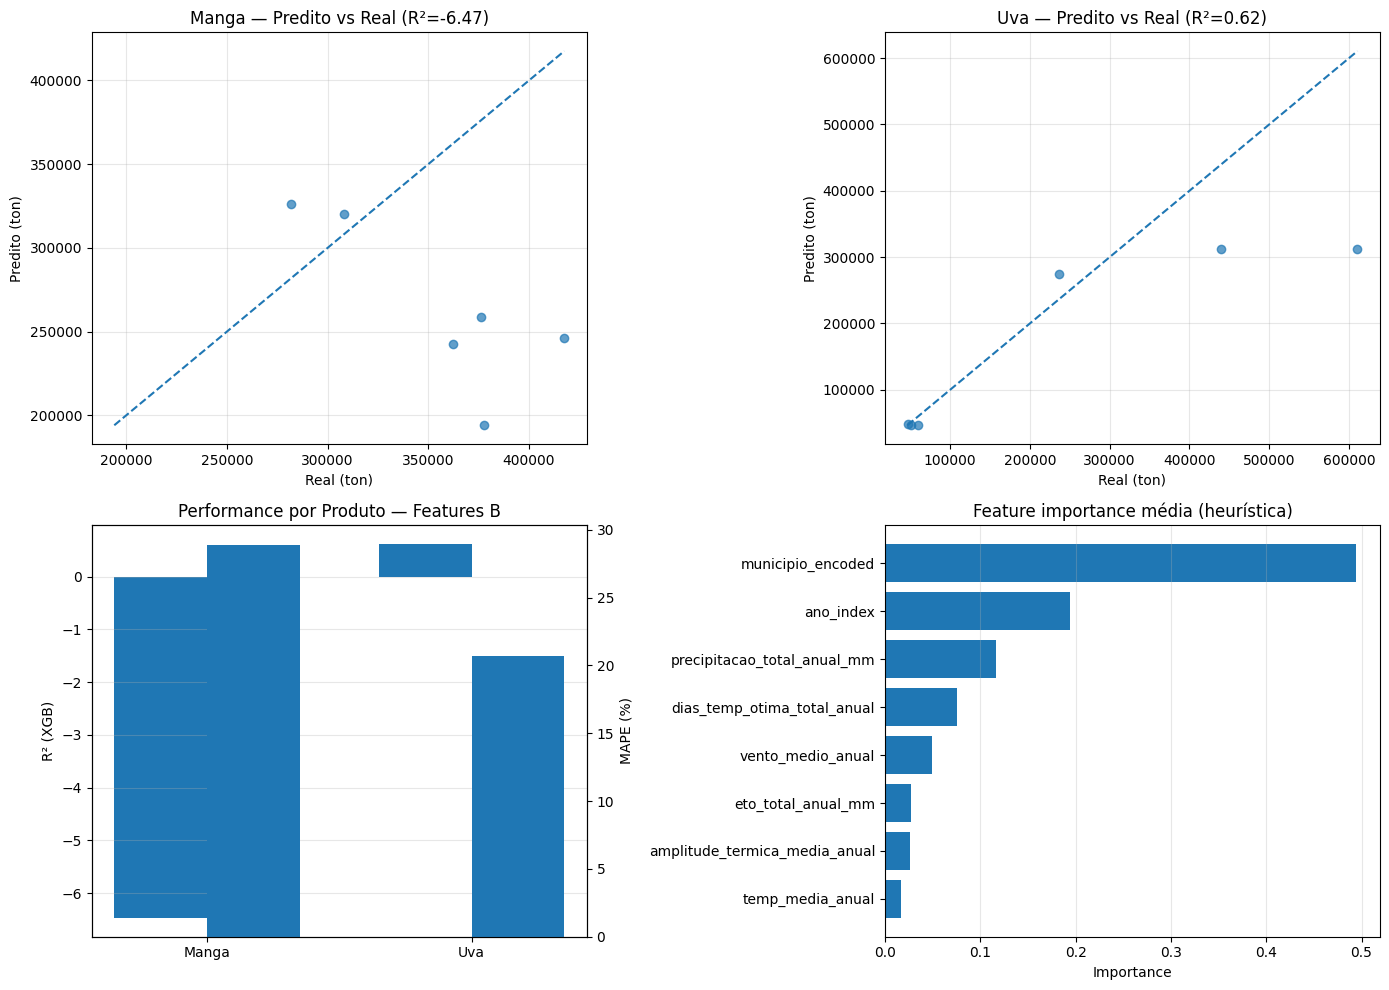

✅ Figura salva em: /content/models/model_results.png


In [14]:
# Preparar figura 2x2
fig = plt.figure(figsize=(14, 10))

# Scatter plots (linha identidade)
for i, prod in enumerate(produtos):
    ax = plt.subplot(2, 2, i + 1)
    res = chosen_results[prod]
    y_true = res["y_true"]
    y_pred = res["y_pred"]
    r2 = res["metrics"]["xgb_test"]["r2"]

    ax.scatter(y_true, y_pred, alpha=0.7)
    lim_min = float(min(y_true.min(), y_pred.min()))
    lim_max = float(max(y_true.max(), y_pred.max()))
    ax.plot([lim_min, lim_max], [lim_min, lim_max], linestyle="--")

    ax.set_title(f"{prod} — Predito vs Real (R²={r2:.2f})")
    ax.set_xlabel("Real (ton)")
    ax.set_ylabel("Predito (ton)")
    ax.grid(True, alpha=0.3)

# Barras de métricas (R² e MAPE)
ax = plt.subplot(2, 2, 3)
r2_vals = [chosen_results[p]["metrics"]["xgb_test"]["r2"] for p in produtos]
mape_vals = [chosen_results[p]["metrics"]["xgb_test"]["mape"] for p in produtos]

x = np.arange(len(produtos))
width = 0.35
ax.bar(x - width/2, r2_vals, width)
ax2 = ax.twinx()
ax2.bar(x + width/2, mape_vals, width)

ax.set_xticks(x)
ax.set_xticklabels(produtos)
ax.set_ylabel("R² (XGB)")
ax2.set_ylabel("MAPE (%)")
ax.set_title(f"Performance por Produto — Features {chosen_label}")
ax.grid(True, alpha=0.3, axis="y")

# Feature importance (média)
ax = plt.subplot(2, 2, 4)
importances = []
feature_names = chosen_results[produtos[0]]["features"]
for p in produtos:
    importances.append(chosen_results[p]["model"].feature_importances_)
imp_mean = np.mean(importances, axis=0)
order = np.argsort(imp_mean)

ax.barh(np.array(feature_names)[order], imp_mean[order])
ax.set_title("Feature importance média (heurística)")
ax.set_xlabel("Importance")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()

fig_path = OUTPUT_DIR / "model_results.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("✅ Figura salva em:", fig_path)


## 9) Salvar modelos e métricas

Salva o modelo XGBoost final por produto e um JSON com:
- features escolhidas
- melhores hiperparâmetros
- métricas no teste
- decisão automática (A ou B)


In [15]:
# Salvar modelos
for prod in produtos:
    model_path = OUTPUT_DIR / f"xgboost_{prod.lower()}.pkl"
    with open(model_path, "wb") as f:
        pickle.dump(chosen_results[prod]["model"], f)
    print("✅ Modelo salvo:", model_path)

# Relatório
report = {
    "project": "Vale do Sao Francisco — Producao Agricola (Clima-only, Annual)",
    "date_trained": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset_path": str(DATASET_PATH),
    "split": {"train_lt_year": YEAR_SPLIT, "test_ge_year": YEAR_SPLIT},
    "features_choice": {
        "A_features": FEATURES_BASE,
        "B_features": FEATURES_WITH_TREND,
        "chosen": chosen_label,
        "avg_r2_A": avg_r2_A,
        "avg_r2_B": avg_r2_B,
        "delta_r2": delta,
        "rule": "choose B if delta_r2 > 0.05 else choose A",
    },
    "models": {},
}

for prod in produtos:
    res = chosen_results[prod]
    report["models"][prod] = {
        "n_train": res["n_train"],
        "n_test": res["n_test"],
        "train_years": res["train_years"],
        "test_years": res["test_years"],
        "best_params": res["best_params"],
        "metrics_test": res["metrics"],
        "features": res["features"],
    }

metrics_path = OUTPUT_DIR / "metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print("✅ Métricas salvas em:", metrics_path)


✅ Modelo salvo: /content/models/xgboost_manga.pkl
✅ Modelo salvo: /content/models/xgboost_uva.pkl
✅ Métricas salvas em: /content/models/metrics.json


In [16]:
"""## Conclusão Analítica"""

print("""
Conclusão:
- O modelo explica bem a produção de uva (R²=0.62).
- O modelo falha para manga, indicando que clima não é o principal driver.
- Demonstra a importância de validar hipóteses e entender o domínio.
""")


Conclusão:
- O modelo explica bem a produção de uva (R²=0.62).
- O modelo falha para manga, indicando que clima não é o principal driver.
- Demonstra a importância de validar hipóteses e entender o domínio.



## 10) Checklist rápido

- [ ] `dataset_ml_anual.csv` em `data/processed/`
- [ ] Rodar este notebook até o fim
- [ ] Verificar se `models/` gerou:
  - `xgboost_uva.pkl`
  - `xgboost_manga.pkl`
  - `metrics.json`
  - `model_results.png`
- [ ] (Opcional) Comparar estabilidade rodando com `RANDOM_SEED` diferente
